In [1]:
import pandas as pd
df = pd.read_csv('archive (1).zip', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [17]:
df.describe()

,label,message
count,5572,5572
unique,2,5142
top,ham,sorry ill call later
freq,4825,30


In [21]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [23]:
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

Duplicates: 430


In [3]:

# Keep only relevant columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Check first rows
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [11]:
import pandas as pd
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Load dataset
df = pd.read_csv('archive (1).zip', encoding='latin-1')

# Keep only relevant columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Show first 5 rows before cleaning
print("Before Cleaning:")
print(df.head())

# Lowercase
df['message'] = df['message'].str.lower()

# Remove punctuation
df['message'] = df['message'].apply(lambda x: ''.join([c for c in x if c not in string.punctuation]))

# Show first 5 rows after cleaning
print("\nAfter Cleaning:")
print(df.head())

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size=0.2, random_state=42)

# Feature extraction
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

print("\nSample feature names:", vectorizer.get_feature_names_out()[:10])

Before Cleaning:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

After Cleaning:
  label                                            message
0   ham  go until jurong point crazy available only in ...
1   ham                            ok lar joking wif u oni
2  spam  free entry in 2 a wkly comp to win fa cup fina...
3   ham        u dun say so early hor u c already then say
4   ham  nah i dont think he goes to usf he lives aroun...

Sample feature names: ['008704050406' '0089my' '0121' '01223585236' '0125698789' '02' '020603'
 '0207' '02070836089' '02072069400']


In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
model = MultinomialNB()
model.fit(X_train_counts, y_train)

# Predict
y_pred = model.predict(X_test_counts)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9811659192825112
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.98      0.87      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



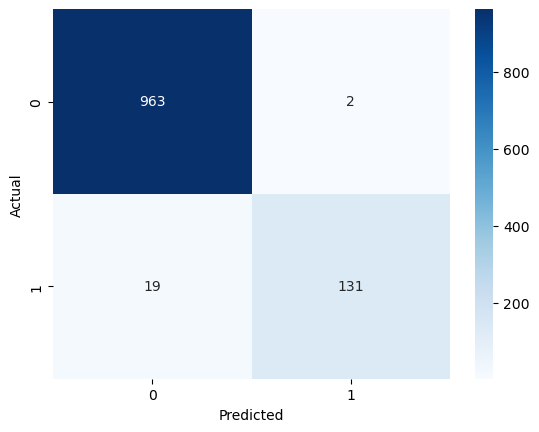

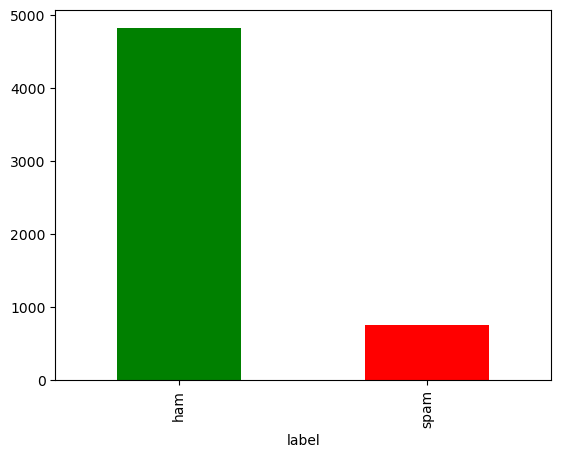

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Spam vs Ham count
df['label'].value_counts().plot(kind='bar', color=['green','red'])
plt.show()